## Mount Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


## Set Project Directory

In [10]:
import os

PROJECT_PATH = "/content/drive/MyDrive/rocket_telemetry_project"

os.chdir(PROJECT_PATH)

print("Working directory:", os.getcwd())

Working directory: /content/drive/MyDrive/rocket_telemetry_project


## Import Required Libraries

In [11]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import model_from_json
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

## Define Paths

In [12]:
SEQUENCE_DIR = "data/sequences"
MODEL_DIR = "models"

METRIC_DIR = "results/metrics"
PLOT_DIR = "results/plots"

os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

## Load Sequences

In [17]:
def load_sequences(channel_id):

    train_path = f"{SEQUENCE_DIR}/{channel_id}_train_seq.npy"
    val_path   = f"{SEQUENCE_DIR}/{channel_id}_val_seq.npy"

    X_tr = np.load(train_path)
    X_val = np.load(val_path)

    print("Original Train:", X_tr.shape)
    print("Original Val:", X_val.shape)

    # Add timestep dimension
    X_tr = np.expand_dims(X_tr, axis=1)
    X_val = np.expand_dims(X_val, axis=1)

    # Repeat to match expected 30 timesteps
    X_tr = np.repeat(X_tr, 30, axis=1)
    X_val = np.repeat(X_val, 30, axis=1)

    print("Fixed Train:", X_tr.shape)
    print("Fixed Val:", X_val.shape)

    return X_tr, X_val

## Load Model Architecture

In [18]:
def load_lstm_model(channel_id):

    arch_path = f"{MODEL_DIR}/architecture_{channel_id}.json"

    assert os.path.exists(arch_path), f"{arch_path} not found"

    with open(arch_path, "r") as f:
        model_json = f.read()

    model = model_from_json(model_json)

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    print("Model architecture loaded")

    return model

## Training Function

In [19]:
def train_model(model, X_tr, X_val, channel_id,
                save_dir="models", epochs=100, batch_size=64):

    checkpoint_path = f"{save_dir}/lstm_ae_{channel_id}.h5"

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_loss',
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

    callbacks = [early_stop, checkpoint, reduce_lr]

    history = model.fit(
        X_tr, X_tr,
        validation_data=(X_val, X_val),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=callbacks,
        verbose=1
    )

    history_dict = history.history

    train_loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]

    best_epoch = np.argmin(val_loss) + 1
    best_val = np.min(val_loss)

    print("\nTraining Summary")
    print("Best epoch:", best_epoch)
    print("Best val_loss:", best_val)
    print("Final train_loss:", train_loss[-1])

    history_path = f"{METRIC_DIR}/{channel_id}_history.json"

    with open(history_path, "w") as f:
        json.dump(history_dict, f)

    print("History saved:", history_path)

    assert val_loss[-1] < val_loss[0], "Model did not improve"
    assert not np.isnan(train_loss).any()
    assert not np.isnan(val_loss).any()

    return model, history

## Run Training

In [20]:
channel_id = "P-1"

X_tr, X_val = load_sequences(channel_id)

model = load_lstm_model(channel_id)

model, history = train_model(
    model,
    X_tr,
    X_val,
    channel_id
)

Original Train: (2547, 41, 96)
Original Val: (284, 41, 96)
Fixed Train: (2547, 30, 41, 96)
Fixed Val: (284, 30, 41, 96)
Model architecture loaded
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0229
Epoch 1: val_loss improved from None to 0.01816, saving model to models/lstm_ae_P-1.h5



Epoch 1: finished saving model to models/lstm_ae_P-1.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - loss: 0.0189 - val_loss: 0.0182 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0134
Epoch 2: val_loss improved from 0.01816 to 0.01530, saving model to models/lstm_ae_P-1.h5



Epoch 2: finished saving model to models/lstm_ae_P-1.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - loss: 0.0125 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0115
Epoch 3: val_loss improved from 0.01530 to 0.01411, saving model to models/lstm_ae_P-1.h5



Epoch 3: finished saving model to models/lstm_ae_P-1.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0109 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0102
Epoch 4: val_loss improved from 0.01411 to 0.01249, saving model to models/lstm_ae_P-1.h5



Epoch 4: finished saving model to models/lstm_ae_P-1.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 0.0097 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0090
Epoch 5: val_loss improved from 0.01249 to 0.01122, saving model to models/lstm_ae_P-1.h5


...


Epoch 93: finished saving model to models/lstm_ae_P-1.h5

Epoch 93: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - loss: 0.0023 - val_loss: 0.0050 - learning_rate: 7.8125e-06
Epoch 94/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0023
Epoch 94: val_loss did not improve from 0.00498
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 0.0022 - val_loss: 0.0050 - learning_rate: 3.9063e-06
Epoch 95/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0023
Epoch 95: val_loss improved from 0.00498 to 0.00498, saving model to models/lstm_ae_P-1.h5



Epoch 95: finished saving model to models/lstm_ae_P-1.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - loss: 0.0022 - val_loss: 0.0050 - learning_rate: 3.9063e-06
Epoch 96/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0023
Epoch 96: val_loss improved from 0.00498 to 0.00498, saving model to models/lstm_ae_P-1.h5



Epoch 96: finished saving model to models/lstm_ae_P-1.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - loss: 0.0022 - val_loss: 0.0050 - learning_rate: 3.9063e-06
Epoch 97/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0023
Epoch 97: val_loss improved from 0.00498 to 0.00498, saving model to models/lstm_ae_P-1.h5



Epoch 97: finished saving model to models/lstm_ae_P-1.h5
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - loss: 0.0022 - val_loss: 0.0050 - learning_rate: 3.9063e-06
Epoch 98/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0023
Epoch 98: val_loss improved from 0.00498 to 0.00498, saving model to models/lstm_ae_P-1.h5



Epoch 98: finished saving model to models/lstm_ae_P-1.h5

Epoch 98: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
40/40 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - loss: 0.0022 - val_loss: 0.0050 - learning_rate: 3.9063e-06
Epoch 99/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0023
Epoch 99: val_loss did not improve from 0.00498
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - loss: 0.0022 - val_loss: 0.0050 - learning_rate: 1.9531e-06
Epoch 100/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0023
Epoch 100: val_loss did not improve from 0.00498
40/40 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - loss: 0.0022 - val_loss: 0.0050 - learning_rate: 1.9531e-06
Restoring model weights from the end of the best epoch: 98.

Training Summary
Best epoch: 98
Best val_loss: 0.00498293898999691
Final train_loss: 0.002248559147119522
History saved: results/metrics/P-1_history.json


## Verify Model Saved

In [21]:
!ls models

architecture_P-1.json  lstm_ae_P-1.h5  scaler_P1.pkl
architecture_P1.json   scaler_P-1.pkl


## Verify Training History

In [22]:
!ls results/metrics

P-1_history.json


## Run Reconstruction Check

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


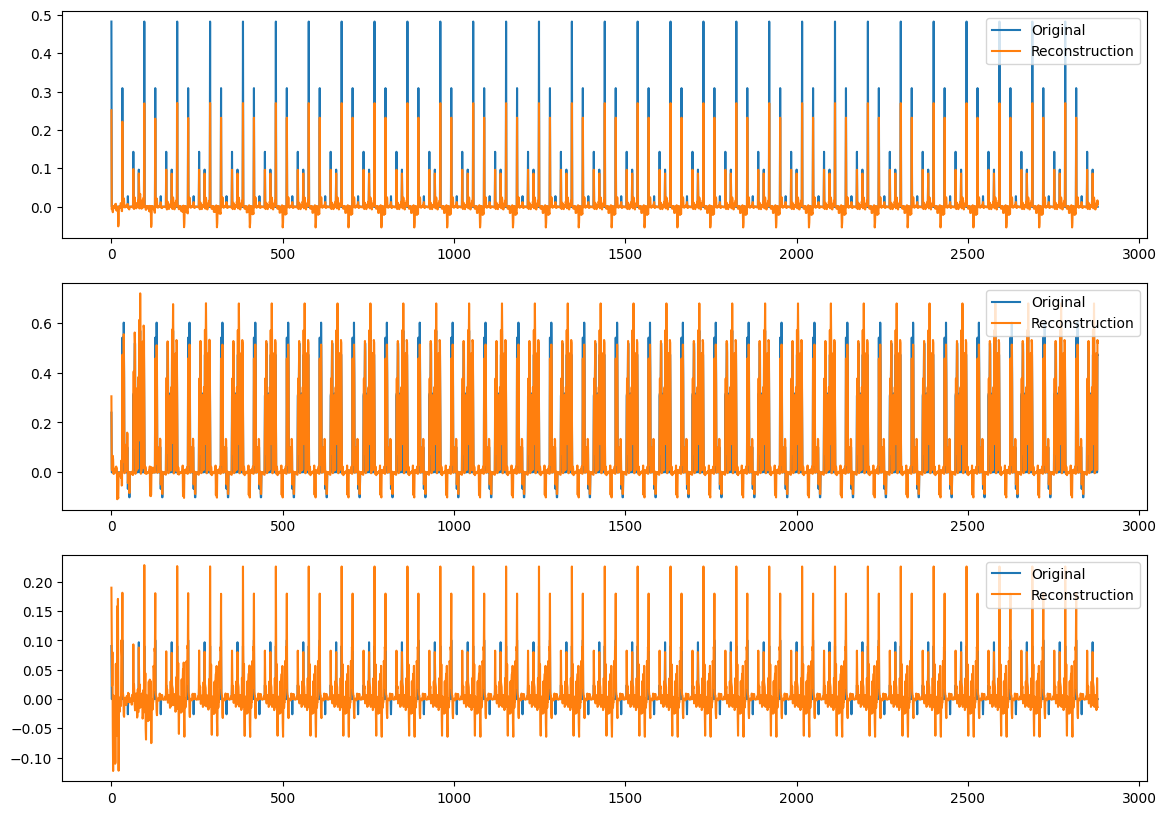

In [23]:
import random
import matplotlib.pyplot as plt

indices = random.sample(range(len(X_tr)), 3)

fig, ax = plt.subplots(3,1, figsize=(14,10))

for i, idx in enumerate(indices):

    sample = X_tr[idx:idx+1]

    reconstruction = model.predict(sample)

    ax[i].plot(sample[0,:,0].flatten(), label="Original")
    ax[i].plot(reconstruction[0,:,0].flatten(), label="Reconstruction")

    ax[i].legend()

plt.show()

## Generate Training Curves

Training curves saved to: results/plots/P-1_training_curves.png


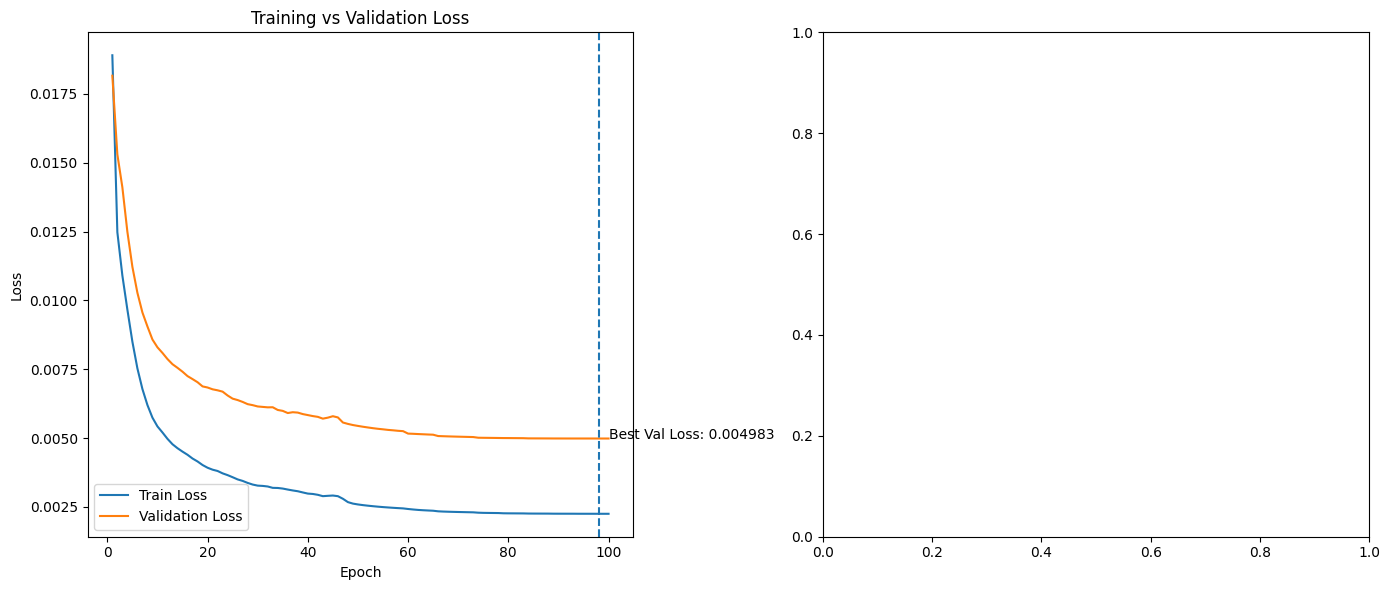

In [26]:
import numpy as np
import matplotlib.pyplot as plt

history_dict = history.history

train_loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = np.arange(1, len(train_loss) + 1)

# Find best epoch
best_epoch = np.argmin(val_loss) + 1
best_val = np.min(val_loss)

# learning rate history
lr_history = history_dict.get("lr", None)

fig, ax = plt.subplots(1, 2, figsize=(14,6))

# -----------------------------
# Panel 1 — Loss Curves
# -----------------------------
ax[0].plot(epochs, train_loss, label="Train Loss")
ax[0].plot(epochs, val_loss, label="Validation Loss")

ax[0].axvline(best_epoch, linestyle="--")

ax[0].annotate(
    f"Best Val Loss: {best_val:.6f}",
    xy=(best_epoch, best_val),
    xytext=(best_epoch + 2, best_val)
)

ax[0].set_title("Training vs Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# -----------------------------
# Panel 2 — Learning Rate
# -----------------------------
if lr_history is not None:

    ax[1].plot(epochs, lr_history)

    for i in range(1, len(lr_history)):
        if lr_history[i] < lr_history[i-1]:
            ax[1].scatter(i+1, lr_history[i], color="red")

    ax[1].set_title("Learning Rate Schedule")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Learning Rate")

plt.tight_layout()

save_path = f"{PLOT_DIR}/{channel_id}_training_curves.png"
plt.savefig(save_path, dpi=150)

print("Training curves saved to:", save_path)

plt.show()

## Save Plot

In [27]:
plt.savefig("results/plots/P-1_training_curves.png", dpi=150)

<Figure size 640x480 with 0 Axes>